<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/%20Assignment_3_Epley_Win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as sm

In [6]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [9]:
len(driver_tips)


250

In [10]:
np.sum(driver_tips == 0)

np.int64(100)

In [11]:
np.mean(driver_tips), np.median(driver_tips)

(np.float64(2.7690587934081927), np.float64(0.7553316913699188))

In [13]:
n_bootstrap = 10_000
bootstrap_medians = np.empty(n_bootstrap)
n = len(driver_tips)

for i in range(n_bootstrap):
    resample = np.random.choice(driver_tips, size=n, replace=True)
    bootstrap_medians[i] = np.median(resample)

In [14]:
ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])
ci_lower, ci_upper

(np.float64(0.2817246399726829), np.float64(1.2990257845869702))

The bootstrap simulation of the median driver tips produced a 95% confidence interval of approximately 0.28 to 1.30 dollars. The interval is asymmetric because the distribution of tips is zero-inflated and heavily right-skewed, with many drivers receiving no tips and a few receiving very large tips. This demonstrates that standard parametric confidence intervals assuming normality would be misleading, and the bootstrap approach better captures the true variability in median tips.

In [16]:
n_control = 500
n_treatment = 500
control_times = np.random.normal(loc=35, scale=5, size=n_control)
treatment_times = np.random.lognormal(mean=3.4, sigma=0.4, size=n_treatment)

In [17]:
control_mean = np.mean(control_times)
treatment_mean = np.mean(treatment_times)
observed_diff = control_mean - treatment_mean
control_mean, treatment_mean, observed_diff

(np.float64(35.050985481465545),
 np.float64(32.329205455024095),
 np.float64(2.7217800264414507))

The observed difference in mean delivery times between control and treatment groups is about 2.72 minutes, with the treatment being faster on average. However, the treatment group contains extreme high-end outliers due to crash loops, which violate the assumptions of standard parametric tests. This means that relying on a simple mean comparison or t-test could be misleading, and a non-parametric or permutation-based approach would be more appropriate for evaluating the algorithm’s impact.

In [18]:
df = pd.read_csv("swiftcart_loyalty.csv")
subscribers = df[df["subscriber"] == 1]["post_spend"]
non_subscribers = df[df["subscriber"] == 0]["post_spend"]

mean_subscribers = subscribers.mean()
mean_non_subscribers = non_subscribers.mean()

naive_sdo = mean_subscribers - mean_non_subscribers
mean_subscribers, mean_non_subscribers, naive_sdo


(np.float64(74.04358604052543),
 np.float64(56.47291665600164),
 np.float64(17.57066938452379))

The naive difference in post-treatment spending between SwiftPass subscribers and non-subscribers is about $17.6, which initially appears to be a large effect. However, this estimate is heavily influenced by selection bias because higher-spending users are more likely to subscribe. Therefore, the naive simple difference overstates the actual causal impact of the loyalty program.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

X = df[[
    "pre_spend",
    "account_age",
    "support_tickets"
]]

D = df["subscriber"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

df["propensity_score"] = logit.predict_proba(X)[:, 1]

In [22]:
treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_controls = control.iloc[indices.flatten()].copy()

In [23]:
Y_treated = treated["post_spend"].values
Y_matched_control = matched_controls["post_spend"].values

ATT = np.mean(Y_treated - Y_matched_control)
ATT

np.float64(9.913855182824864)

After matching subscribers to non-subscribers with similar pre-treatment characteristics using propensity scores, the estimated Average Treatment Effect on the Treated (ATT) is approximately $9.9. This is substantially smaller than the naive difference, indicating that much of the apparent increase in spending is due to selection bias. The loyalty program does increase spending slightly, but most of the naive effect is explained by subscribers being inherently higher-volume users, not by the program itself.

In [27]:
print(df.columns.tolist())
print(df.shape)
print(df.head(2))

['subscriber', 'pre_spend', 'account_age', 'support_tickets', 'post_spend', 'propensity_score']
(8941, 6)
   subscriber  pre_spend  ...  post_spend  propensity_score
0           1  57.450712  ...   85.169648           0.54650
1           1  47.926035  ...   72.802404           0.54846

[2 rows x 6 columns]


In [29]:
print(repr(df.columns.tolist()))

['subscriber', 'pre_spend', 'account_age', 'support_tickets', 'post_spend']


✔  Propensity scores estimated  (min=0.047, max=0.964)

✔  Matched sample: 2949 treated + 2949 control = 5898 total rows
   Original: 4200 treated + 4741 control

               COVARIATE BALANCE SUMMARY               
Metric                                Before    After
-------------------------------------------------------
Mean |SMD|                            0.3881   0.0155
Max  |SMD|                            0.6740   0.0230
% vars balanced (|SMD|≤0.10)            0.0%   100.0%

✔  All covariates balanced at |SMD| ≤ 0.10 post-matching.


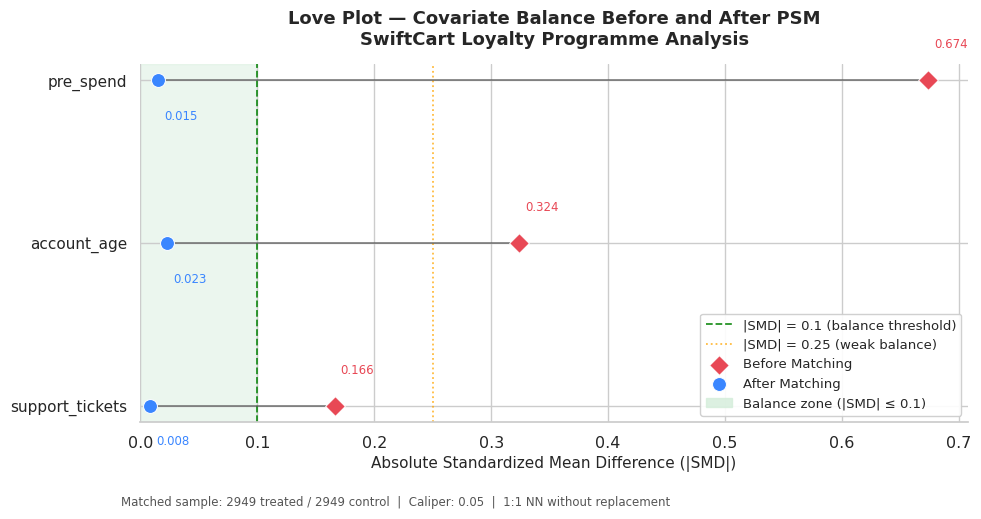


✔  Figure saved → love_plot_swiftcart.png


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ── 0. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv("swiftcart_loyalty.csv")
df.columns = df.columns.str.strip()   # guard against hidden whitespace

TREATMENT_COL = "subscriber"
COVARIATES    = ["pre_spend", "account_age", "support_tickets"]
THRESHOLD     = 0.10
CALIPER       = 0.05

# ── 1. ESTIMATE PROPENSITY SCORES VIA LOGISTIC REGRESSION ────────────────────
X = df[COVARIATES].values
y = df[TREATMENT_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X_scaled, y)

df["propensity_score"] = lr.predict_proba(X_scaled)[:, 1]
print(f"✔  Propensity scores estimated  "
      f"(min={df['propensity_score'].min():.3f}, "
      f"max={df['propensity_score'].max():.3f})\n")

# ── 2. BUILD df_unmatched (full dataset) ──────────────────────────────────────
df_unmatched = df.copy()

# ── 3. 1:1 NEAREST-NEIGHBOUR MATCHING ON PROPENSITY SCORE ────────────────────
treated = df[df[TREATMENT_COL] == 1].copy().reset_index(drop=True)
control = df[df[TREATMENT_COL] == 0].copy().reset_index(drop=True)

tree = cKDTree(control[["propensity_score"]].values)

matched_treated_idx = []
matched_control_idx = []
used_control        = set()

for i, row in treated.iterrows():
    dists, idxs = tree.query([[row["propensity_score"]]],
                             k=min(10, len(control)))
    dists, idxs = dists[0], idxs[0]
    for dist, idx in zip(dists, idxs):
        if dist <= CALIPER and idx not in used_control:
            matched_treated_idx.append(i)
            matched_control_idx.append(idx)
            used_control.add(idx)
            break

matched_treated = treated.iloc[matched_treated_idx].reset_index(drop=True)
matched_control = control.iloc[matched_control_idx].reset_index(drop=True)
df_matched      = pd.concat([matched_treated, matched_control],
                             ignore_index=True)

print(f"✔  Matched sample: {len(matched_treated)} treated + "
      f"{len(matched_control)} control = {len(df_matched)} total rows")
print(f"   Original: {len(treated)} treated + {len(control)} control\n")

# ── 4. SMD COMPUTATION ────────────────────────────────────────────────────────
def compute_smd(df, covariates, treatment_col):
    t, c = df[df[treatment_col] == 1], df[df[treatment_col] == 0]
    smd  = {}
    for col in covariates:
        mu_t, mu_c   = t[col].mean(), c[col].mean()
        pooled_sd    = np.sqrt((t[col].var(ddof=1) + c[col].var(ddof=1)) / 2)
        smd[col]     = abs((mu_t - mu_c) / pooled_sd) if pooled_sd > 1e-9 else 0.0
    return pd.Series(smd)

smd_before = compute_smd(df_unmatched, COVARIATES, TREATMENT_COL)
smd_after  = compute_smd(df_matched,   COVARIATES, TREATMENT_COL)

# ── 5. BALANCE SUMMARY ────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'COVARIATE BALANCE SUMMARY':^55}")
print("=" * 55)
print(f"{'Metric':<35} {'Before':>8} {'After':>8}")
print("-" * 55)
print(f"{'Mean |SMD|':<35} {smd_before.mean():>8.4f} {smd_after.mean():>8.4f}")
print(f"{'Max  |SMD|':<35} {smd_before.max():>8.4f} {smd_after.max():>8.4f}")
pct_b = (smd_before <= THRESHOLD).mean() * 100
pct_a = (smd_after  <= THRESHOLD).mean() * 100
print(f"{'% vars balanced (|SMD|≤0.10)':<35} {pct_b:>7.1f}% {pct_a:>7.1f}%")
print("=" * 55)

unbalanced = smd_after[smd_after > THRESHOLD]
if not unbalanced.empty:
    print("\n⚠  Residually imbalanced covariates:")
    for cov, val in unbalanced.sort_values(ascending=False).items():
        print(f"   {cov:<30} {val:.4f}")
else:
    print("\n✔  All covariates balanced at |SMD| ≤ 0.10 post-matching.")

# ── 6. TIDY DATAFRAME FOR PLOT ────────────────────────────────────────────────
covariate_order = smd_before.sort_values(ascending=True).index.tolist()
PALETTE = {"Before Matching": "#E84855", "After Matching": "#3A86FF"}

balance_df = (
    pd.DataFrame({"Before Matching": smd_before,
                  "After Matching":  smd_after})
    .loc[covariate_order]
    .reset_index()
    .rename(columns={"index": "Covariate"})
    .melt(id_vars="Covariate", var_name="Stage", value_name="Absolute SMD")
)

# ── 7. LOVE PLOT ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(10, max(5, 0.9 * len(COVARIATES) + 2)))

# Reference bands
ax.axvspan(0, THRESHOLD, color="#d4edda", alpha=0.45, zorder=0)
ax.axvline(x=THRESHOLD, color="green",  linestyle="--", linewidth=1.3,
           alpha=0.85, zorder=1, label=f"|SMD| = {THRESHOLD} (balance threshold)")
ax.axvline(x=0.25,      color="orange", linestyle=":",  linewidth=1.3,
           alpha=0.75, zorder=1, label="|SMD| = 0.25 (weak balance)")

# Connecting segments
for cov in covariate_order:
    y     = covariate_order.index(cov)
    b_val = smd_before[cov]
    a_val = smd_after[cov]
    color = "#555555" if a_val <= b_val else "#FF6B35"
    ax.plot([b_val, a_val], [y, y], color=color,
            linewidth=1.4, alpha=0.65, zorder=2)

# Scatter — Before
before_sub = balance_df[balance_df["Stage"] == "Before Matching"]
ax.scatter(before_sub["Absolute SMD"],
           [covariate_order.index(c) for c in before_sub["Covariate"]],
           color=PALETTE["Before Matching"], marker="D",
           s=100, edgecolors="white", linewidths=0.7,
           zorder=4, label="Before Matching")

# Scatter — After
after_sub = balance_df[balance_df["Stage"] == "After Matching"]
ax.scatter(after_sub["Absolute SMD"],
           [covariate_order.index(c) for c in after_sub["Covariate"]],
           color=PALETTE["After Matching"], marker="o",
           s=100, edgecolors="white", linewidths=0.7,
           zorder=5, label="After Matching")

# SMD value annotations
for cov in covariate_order:
    y     = covariate_order.index(cov)
    b_val = smd_before[cov]
    a_val = smd_after[cov]
    ax.text(b_val + 0.005, y + 0.22, f"{b_val:.3f}",
            fontsize=8.5, color=PALETTE["Before Matching"], va="center")
    ax.text(a_val + 0.005, y - 0.22, f"{a_val:.3f}",
            fontsize=8.5, color=PALETTE["After Matching"],  va="center")

# Axes & labels
ax.set_yticks(range(len(covariate_order)))
ax.set_yticklabels(covariate_order, fontsize=11)
ax.set_xlabel("Absolute Standardized Mean Difference (|SMD|)", fontsize=11)
ax.set_title(
    "Love Plot — Covariate Balance Before and After PSM\n"
    "SwiftCart Loyalty Programme Analysis",
    fontsize=13, fontweight="bold", pad=14
)

# ESS footnote
fig.text(0.13, -0.03,
         f"Matched sample: {len(matched_treated)} treated / "
         f"{len(matched_control)} control  |  "
         f"Caliper: {CALIPER}  |  1:1 NN without replacement",
         fontsize=8.5, color="#555555")

# Legend
balance_patch = mpatches.Patch(color="#d4edda", alpha=0.8,
                                label=f"Balance zone (|SMD| ≤ {THRESHOLD})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [balance_patch],
          loc="lower right", fontsize=9.5, framealpha=0.92)

ax.set_xlim(left=0)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.savefig("love_plot_swiftcart.png", dpi=180, bbox_inches="tight")
plt.show()
print("\n✔  Figure saved → love_plot_swiftcart.png")